In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..')) 

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import HTML, display
from acpype.topol import ACTopol, MolTopol
import param_tool as pt
import py3Dmol
import MDAnalysis as mda

import nglview as nv
from parmed import amber, gromacs


IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(
/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(


##  Генерация фаила топологии (.itp) при помощи библиотеки acpype
*Важный момент: acpype готов принимать в себя только единичные остатки аминокислот. При попытке параметризовать ди-/три-/поли-мер выводит следующие ошибки:*\
`ERROR: more than one residue detected '{'UNK', 'GLY'}'` \
`ERROR: verify your input file 'GRG_CITsmi.mol2'. Aborting ...`\
`ERROR: Only ONE Residue is allowed for ACPYPE to work`


In [2]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_1M


In [2]:
def path_dict(path_list):
    mol_dict = {} 
    if isinstance(path_list, str):
        name = os.path.basename(path_list).split('.')[0]
        mol_dict[name] = path_list
    if isinstance(path_list, list):
        for path in path_list:
            name = os.path.basename(path).split('.')[0]
            mol_dict[name] = path
    return mol_dict

### Наборы молекул для параметризации

#### SMI polymer

In [ ]:
mol_dict = path_dict(['moleculse/RA_CIT.smiles',
                      'moleculse/GRG_CIT.smiles',
                      'moleculse/GR_CIT.smiles'])
smi_dict = pt.read_file(mol_dict)
smi_dict

{'RA_CIT': '[H]N([H])C(=O)N([H])C([H])([H])C([H])([H])C([H])([H])[C@]([H])(C(=O)N([H])C([H])(C([O-])=O)C([H])([H])[H])[N+]([H])([H])[H]',
 'GRG_CIT': '[H]N([H])C(=O)N([H])C([H])([H])C([H])([H])C([H])([H])C([H])(N([H])C(=O)C([H])([H])[N+]([H])([H])[H])C(=O)N([H])C([H])([H])C([O-])=O',
 'GR_CIT': '[H]N([H])C(=O)N([H])C([H])([H])C([H])([H])C([H])([H])[C@]([H])(N([H])C(=O)C([H])([H])[N+]([H])([H])[H])C([O-])=O'}

#### MOL substructure

In [41]:
os.chdir('/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT')

## Использование acpype 

### SMI 

In [34]:
PTM_folder = 'Lysine_1M'

In [35]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_1M


In [36]:
os.chdir(f'/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/{PTM_folder}')

In [39]:
test_smi = pt.read_file([f'molecules/substructure/{PTM_folder}_rn_H.smiles',
              # 'moleculse/substructure/R_CIT.smiles',
              # 'moleculse/substructure/CR_CIT.smiles'
                        ])
test_chem = pt.smi_to_chem(test_smi, addH=False, sanitize=False)
IPythonConsole.drawOptions.addAtomIndices = True

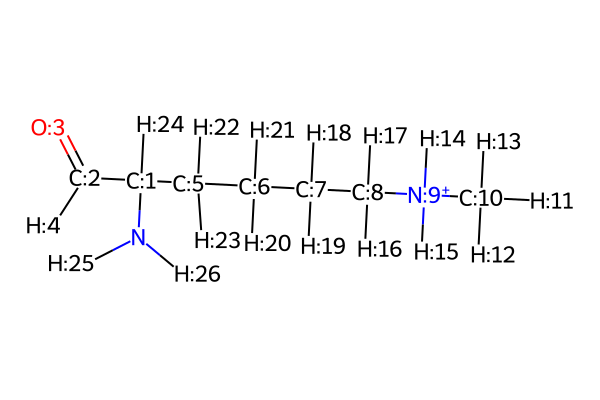

In [41]:
pt.draw_mol_with_atom_index(test_chem[f'{PTM_folder}_rn_H'])

In [27]:
def renumber_atoms(mol):
    for atom in mol.GetAtoms():
        atom.SetProp('molAtomMapNumber', str(int(atom.GetIdx()) + 1))
    return mol

In [28]:
renum_test_chem = {name: renumber_atoms(mol) for name, mol in test_chem.items()}

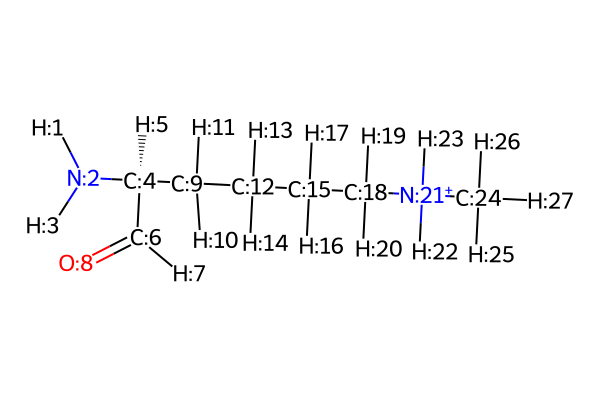

In [29]:
IPythonConsole.drawOptions.addAtomIndices = False
renum_test_chem[PTM_folder]

In [23]:
chem_dict = pt.smi_to_chem(smi_dict, sanitize=False, addH=True)
chem_dict

NameError: name 'smi_dict' is not defined

In [ ]:
chem_dict['NR_CIT'].GetNumAtoms()

25

#### SMI ACTopol

In [ ]:
# os.makedirs('Acpype_data', exist_ok=True) 

In [42]:
os.chdir(f'/home/_projects/2022_md_FRET_nv/param_R_CIT/{PTM_folder}/Acpype_data')        

In [44]:
test_smi['Lysine_1M_rn_H']

'[N]([C:1]([C:2](=[O:3])[H:26])([C:4]([C:5]([C:6]([C:7]([N+:8]([C:9]([H:10])([H:11])[H:12])([H:13])[H:14])([H:15])[H:16])([H:17])[H:18])([H:19])[H:20])([H:21])[H:22])[H:23])([H:24])[H:25]'

In [46]:
molecule = ACTopol(inputFile=test_smi['Lysine_1M_rn_H'], 
                   chargeType="gas", 
                   atomType='amber', 
                   outTopol='gmx',
                   basename=f'{full_mol_name}_smi', 
                   chargeVal=0, 
                      )

molecule.createACTopol()
molecule.createMolTopol()

ERROR: more than one residue detected '{'MOL', '<1>'}'
ERROR: verify your input file 'Lysine_1M_rn_H_3D_smi.mol2'. Aborting ...
ERROR: Only ONE Residue is allowed for ACPYPE to work


Exception: Only ONE Residue is allowed for ACPYPE to work

==> Timed out! Process 11791 killed, max exec time (10800s) exceeded


### PDB

In [4]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_1M


In [3]:
PTM_folder = 'Lysine_1M'


In [4]:
os.chdir(f'/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/{PTM_folder}')

In [5]:
path = 'molecules/substructure/Lysine_1M_rn_H_3D.pdb'
param_file = os.path.basename(path)
full_mol_name = param_file.split('.')[0]
print(full_mol_name)
# NR_CIT = RRR.select_atoms('resnum 1')
param_mol = mda.Universe(path)
nv.show_mdanalysis(param_mol)
# NR_CIT

Lysine_1M_rn_H_3D


NGLWidget()

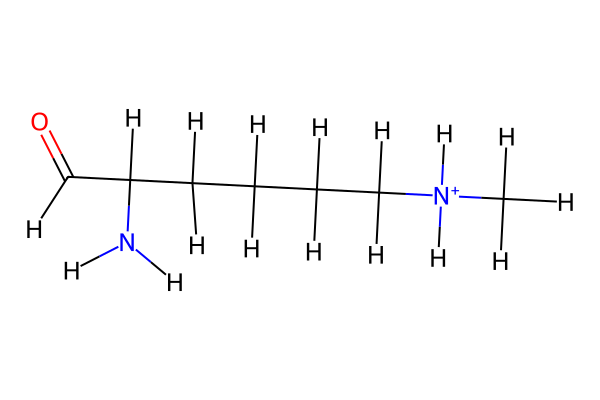

In [6]:
param_chem = pt.pdb_to_chem(path)
param_chem[full_mol_name]

In [7]:
param_file

'Lysine_1M_rn_H_3D.pdb'

In [10]:
# NR_CIT.write('moleculse/NR_CIT_pdb.pdb')

In [8]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_1M


#### PDB ACTopol

In [10]:
os.chdir(f'/home/_projects/2022_md_FRET_nv/param_R_CIT/{PTM_folder}/Acpype_data/')        

In [11]:
!obabel ../molecules/substructure/Lysine_1M_rn_H_3D.pdb -O ../molecules/substructure/Lysine_1M_rn_H_3D.mdl

1 molecule converted


In [12]:
# molecule = ACTopol(inputFile = f'../molecules/substructure/{param_file}', 
molecule = ACTopol(inputFile = f'../molecules/substructure/{full_mol_name}.mdl', 
                   
                   chargeType="gas",  # bcc
                   atomType='amber', 
                   outTopol='gmx', 
                   basename=full_mol_name, 
                   chargeVal=1, 
                   # debug=True
                   )
molecule.createACTopol()
molecule.createMolTopol()

==> ... charge set to 1
==> Executing Antechamber...
==> * Antechamber OK *
==> * Parmchk OK *
==> Executing Tleap...
==> * Tleap OK *
==> Removing temporary files...


In [15]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_1M/Acpype_data/Lysine_1M_rn_H_3D.acpype


In [14]:
from parmed import amber, gromacs

In [32]:
top_L = gromacs.GromacsTopologyFile(f'{full_mol_name}.acpype/{full_mol_name}_GMX.itp')
residue = pt.pdb_to_chem(f'../molecules/substructure/{param_file}')
residue

{'Lysine_1M_rn_H_3D': <rdkit.Chem.rdchem.Mol at 0x7f38e6242510>}

In [49]:
for top_atom, chem_atom in zip(top_L, residue[full_mol_name].GetAtoms()):
    top_atom.name = chem_atom.GetProp('AtomName')
    top_atom.residue.name = 'K1M'

In [51]:
top_L.save(f'{full_mol_name}.acpype/{full_mol_name}_mod.itp', format='gromacs')

## Ручной вариант

In [34]:
os.chdir('/home/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_1M/Acpype_data/test/')    

In [33]:
%%bash

antechamber -i ../../molecules/substructure/Lysine_1M_rn_H_3D.pdb -fi pdb -o Lysine_1M_rn_H_3D_gas_amber.mol2 -fo mol2 -c gas -nc 1 -m 1 -s 2 -df 2 -at amber -pf n 
antechamber -i ../../molecules/substructure/Lysine_1M_rn_H_3D.pdb -fi pdb -o Lysine_1M_rn_H_3D_gas_amber.prepin -fo prepi -c gas -j 4 -at gaff
parmchk2 -i Lysine_1M_rn_H_3D_gas_amber.mol2 -f mol2 -o Lysine_1M_rn_H_3D_AC.frcmod -p /tmp/parm10gaffff14SB.dat
parmchk -i Lysine_1M_rn_H_3D_AC.prepin -o Lysine_1M_rn_H_3D_AC.frcmod -f prepi -p /tmp/parm10gaffff14SB.dat


Welcome to antechamber 19.0: molecular input file processor.

acdoctor mode is on: check and diagnose problems in the input file.
-- Check Format for pdb File --
   Status: pass
-- Check Unusual Elements --
   Status: pass
-- Check Open Valences --
   Status: pass
-- Check Geometry --
      for those bonded   
      for those not bonded   
   Status: pass
-- Check Weird Bonds --
   Status: pass
-- Check Number of Units --
   Status: pass
acdoctor mode has completed checking the input file.

Running: /home/n_kristovsky/.conda/envs/topmol2/bin/bondtype -j full -i ANTECHAMBER_BOND_TYPE.AC0 -o ANTECHAMBER_BOND_TYPE.AC -f ac

Running: /home/n_kristovsky/.conda/envs/topmol2/bin/atomtype -i ANTECHAMBER_AC.AC0 -o ANTECHAMBER_AC.AC -p amber
Running: /home/n_kristovsky/.conda/envs/topmol2/bin/atomtype -i ANTECHAMBER_GAS.AC -o ANTECHAMBER_GAS_AT.AC -d /home/n_kristovsky/.conda/envs/topmol2/dat/antechamber/ATOMTYPE_GAS.DEF



In [35]:
%%bash

antechamber -i ../../molecules/substructure/Lysine_1M_rn_H_3D.pdb -fi pdb -o Lysine_1M_rn_H_3D_gas_amber.prepin -fo prepi -c gas -j 4 -nc 1 -m 1 -s 2 -df 2 -at amber -pf n 
# antechamber -i ../../molecules/substructure/Lysine_1M_rn_H_3D.pdb -fi pdb -o Lysine_1M_rn_H_3D_gas_amber.prepin -fo prepi -c gas -j 4 -at gaff
# parmchk2 -i Lysine_1M_rn_H_3D_gas_amber.mol2 -f mol2 -o Lysine_1M_rn_H_3D_AC.frcmod -p /tmp/parm10gaffff14SB.dat

In [37]:
%%bash
parmchk2 -i Lysine_1M_rn_H_3D_gas_amber.prepin -o Lysine_1M_rn_H_3D_gas_amber.frcmod -f prepi -p /tmp/parm10gaffff14SB.dat

In [19]:
molecule.execParmchk()

ERROR: ++++++++++start_quote+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ERROR: Cannot open file (Lysine_1M_rn_H_3D_gas_amber.mol2) with mode (r).
No such file or directory
ERROR: ++++++++++end_quote+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


True

In [44]:
molecule.createMolTopol()

FileNotFoundError: [Errno 2] No such file or directory: 'Lysine_1M_rn_H_3D_AC.prmtop'

In [16]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


In [15]:
os.chdir('/home/_projects/2022_md_FRET_nv/param_R_CIT')        

In [17]:
acpype_name = 'Lysin_1M_ACC_rn_H_3D'
top = gromacs.GromacsTopologyFile(f"Acpype_data/{acpype_name}.acpype/{acpype_name}_GMX.itp")

In [18]:
for a in top.atoms:
    print(a.name, a.atom_type,a.idx)

N NT 0
CA CT 1
C C 2
O O 3
CB CT 4
CG CT 5
CD CT 6
CE CT 7
N2 N 8
C7 C 9
O2 O 10
C8 CT 11
H7 HC 12
H2 HC 13
H3 HC 14
C9 CT 15
H4 H1 16
H5 H1 17
H6 H1 18
HE2 H1 19
HE3 H1 20
HD2 HC 21
HD3 HC 22
HG2 HC 23
HG3 HC 24
HB2 HC 25
HB3 HC 26
HA H1 27
H1 H 28
HM H 29
HM1 HA 30


In [8]:
for name, mol in smi_dict.items():
# Проверяем существование папки Acpype и создаём её, если нужно

# Путь к файлу MDL, который будет создан

    # molecul = 'mol'
# Создание объекта ACTopol и выполнение методов
    molecule = ACTopol(mol, chargeType="gas", atomType='gaff2', outTopol='gmx',
                       basename=name+'smi', chargeVal=0, 
                       # amb2gmx=True
                      )


    molecule.createACTopol()
    molecule.createMolTopol()


==> ... charge set to 0
==> Executing Antechamber...
==> * Antechamber OK *
==> * Parmchk OK *
==> Executing Tleap...
==> * Tleap OK *
==> Removing temporary files...
==> Using OpenBabel v.3.1.0

==> Writing GROMACS files

==> Disambiguating lower and uppercase atomtypes in GMX top file, even if identical.

==> Writing GMX dihedrals for GMX 4.5 and higher.

==> Writing pickle file R_CITsmi.pkl
==> Removing temporary files...
==> ... charge set to 0
==> Executing Antechamber...
==> * Antechamber OK *
==> * Parmchk OK *
==> Executing Tleap...
==> * Tleap OK *
==> Removing temporary files...
==> Using OpenBabel v.3.1.0

==> Writing GROMACS files

==> Disambiguating lower and uppercase atomtypes in GMX top file, even if identical.

==> Writing GMX dihedrals for GMX 4.5 and higher.

==> Writing pickle file NR_CITsmi.pkl
==> Removing temporary files...
==> ... charge set to 0
==> Executing Antechamber...
==> * Antechamber OK *
==> * Parmchk OK *
==> Executing Tleap...
==> * Tleap OK *
==> Re

In [39]:
os.chdir('/home/_projects/2022_md_FRET_nv/param_R_CIT')        

In [40]:
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (1200, 400)

In [41]:

mol = Chem.MolFromMolFile('Acpype_data/NR_CIT.acpype/CR_CIT.mol',removeHs=False, sanitize=False)
mol

OSError: Bad input file Acpype_data/NR_CIT.acpype/CR_CIT.mol

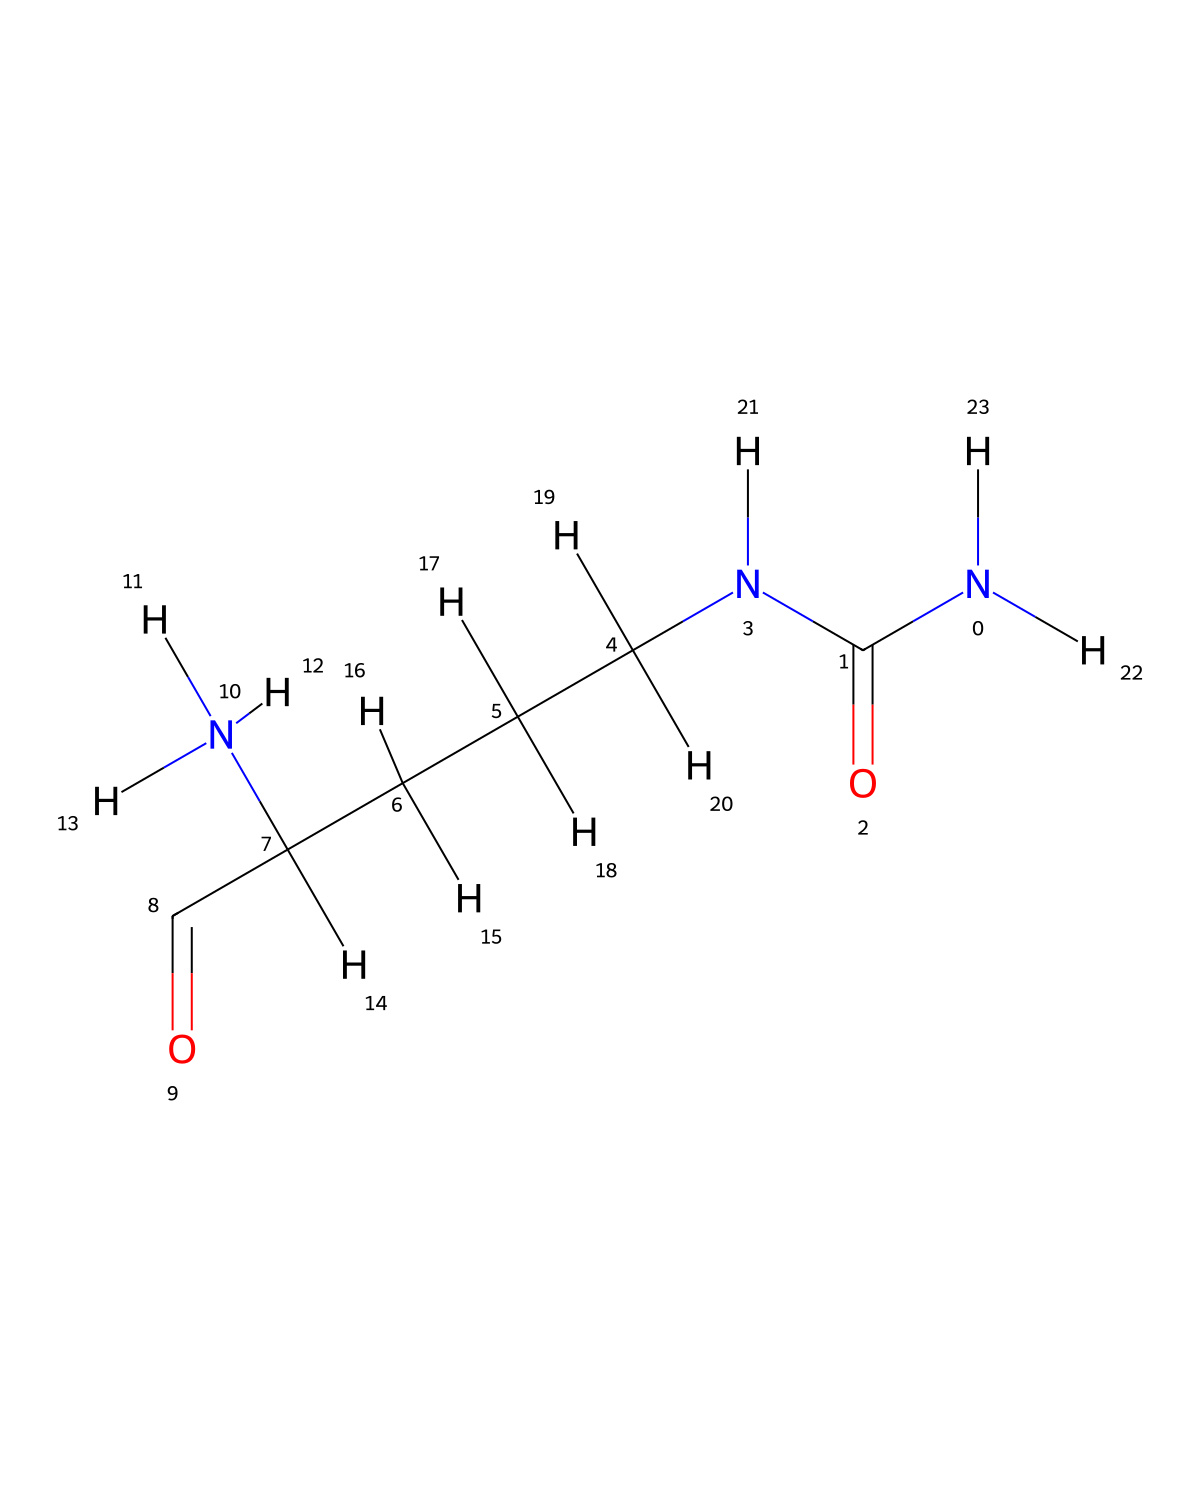

In [18]:

mol = Chem.MolFromMolFile('NR_CITmol.acpype/NR_CIT.mol',removeHs=False, sanitize=False)
mol

In [14]:
R_CIT = pt.smi_to_chem(mol_dict)
R_CIT['R_CIT']

[12:00:45] SMILES Parse Error: syntax error while parsing: moleculse/substructure/R_CIT.smiles
[12:00:45] SMILES Parse Error: Failed parsing SMILES 'moleculse/substructure/R_CIT.smiles' for input: 'moleculse/substructure/R_CIT.smiles'


ArgumentError: Python argument types in
    rdkit.Chem.rdmolops.AddHs(NoneType)
did not match C++ signature:
    AddHs(RDKit::ROMol mol, bool explicitOnly=False, bool addCoords=False, boost::python::api::object onlyOnAtoms=None, bool addResidueInfo=False)

In [6]:
!pwd

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
ERROR: error getting working directory name: no such file or directory
>/usr/share/modules/init/bash: line 58: export: _moduleraw: not a function
pwd: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory


In [40]:
smi_dict = pt.read_file(mol_dict)
smi_dict
chem_dict = {}
for name ,smi in smi_dict.items():
    chem_dict[name] = Chem.MolFromSmiles(smi, sanitize=False)
chem_dict
# mol = pt.smi_to_chem(mol)
# mol['R_CIT']

{'R_CIT': <rdkit.Chem.rdchem.Mol at 0x7f7f32c2de20>,
 'NR_CIT': <rdkit.Chem.rdchem.Mol at 0x7f7f32c2d880>,
 'CR_CIT': <rdkit.Chem.rdchem.Mol at 0x7f7f33143e80>}

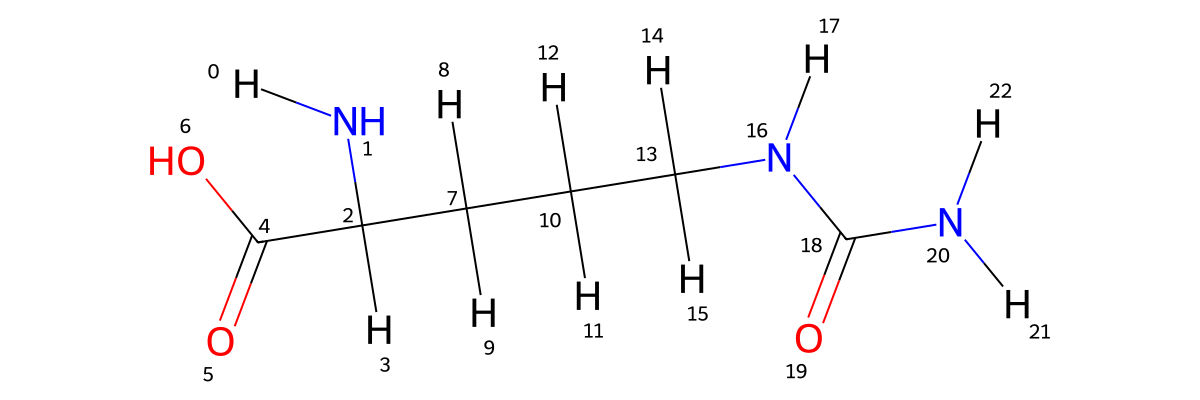

In [47]:
chem_dict['CR_CIT']

In [34]:
def show_mol2(mol2, maxIters=200,  **kwarg):
    mol = Chem.MolFromMol2File(mol2,  **kwarg)
    # if addh:
    #     mol = Chem.AddHs(mol)

    # Оптимизация 3D-структуры 
    AllChem.EmbedMolecule(mol, ignoreSmoothingFailures=True)
    AllChem.MMFFOptimizeMolecule(mol, maxIters=maxIters)
    
    # Создание объекта для 3D-визуализации
    view = py3Dmol.view(width=600, height=400)

    # Добавление модели молекулы
    mblock = Chem.MolToMolBlock(mol)
    view.addModel(mblock, 'mol')

    # Настройка стиля
    view.setStyle({'stick': {}})

    # Масштабирование и отображение
    view.zoomTo()
    view.show()

In [45]:
def show_mol2(mol2, maxIters=200, **kwarg):
    try:
        with open(mol2, 'r') as f:
            mol2_data = f.read()
        
        # Создаем молекулу без санитизации
        mol = Chem.MolFromMol2Block(mol2_data, sanitize=False, removeHs=kwarg.get('removeHs', True))
        
        if mol is None:
            raise ValueError("Ошибка при чтении файла mol2.")
        
        # Применение минимальных изменений для обеспечения корректной валентности
        for atom in mol.GetAtoms():
            atom.UpdatePropertyCache(strict=False)
            if atom.GetExplicitValence() > atom.GetTotalDegree():
                atom.SetNoImplicit(True)
                atom.UpdatePropertyCache(strict=False)
        
        # Попытка санитизации молекулы после ручной правки валентности с игнорированием ошибок
        try:
            Chem.SanitizeMol(mol, Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_PROPERTIES)
        except Exception as e:
            print(f"Валентность некоторых атомов остается некорректной: {e}")
        
        # Добавление водородов, если это необходимо
        if kwarg.get('addHs', False):
            mol = Chem.AddHs(mol)

        # Оптимизация 3D-структуры 
        AllChem.EmbedMolecule(mol, ignoreSmoothingFailures=True)
        AllChem.MMFFOptimizeMolecule(mol, maxIters=maxIters)
        
        # Создание объекта для 3D-визуализации
        view = py3Dmol.view(width=600, height=400)

        # Добавление модели молекулы
        mblock = Chem.MolToMolBlock(mol)
        view.addModel(mblock, 'mol')

        # Настройка стиля
        view.setStyle({'stick': {}})

        # Масштабирование и отображение
        view.zoomTo()
        view.show()
    except Exception as e:
        print(f"Ошибка: {e}")